In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import xgboost as xgb

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load fingerprints and labels
X = np.load("data/egfr_fingerprints.npy")
df = pd.read_csv("data/egfr_features_and_labels.csv")
y = df['label'].values

print("Fingerprints shape:", X.shape)
print("Labels shape:", y.shape)
print("Class distribution:", np.bincount(y))

Fingerprints shape: (13518, 2048)
Labels shape: (13518,)
Class distribution: [4803 8715]


In [3]:
# Stratified 80/20 split to preserve the active/inactive ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train set:", X_train.shape, "| Test set:", X_test.shape)
print("Train class distribution:", np.bincount(y_train))
print("Test class distribution:", np.bincount(y_test))

# Random Forest baseline
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',  # handles the moderate 64.5/35.5 class imbalance
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Evaluate on the held-out test set
rf_probs = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)
print(f"\nRandom Forest ROC-AUC: {rf_auc:.3f}")
print(classification_report(y_test, rf.predict(X_test), target_names=['Inactive', 'Active']))

Train set: (10814, 2048) | Test set: (2704, 2048)
Train class distribution: [3842 6972]
Test class distribution: [ 961 1743]

Random Forest ROC-AUC: 0.945
              precision    recall  f1-score   support

    Inactive       0.81      0.85      0.83       961
      Active       0.91      0.89      0.90      1743

    accuracy                           0.88      2704
   macro avg       0.86      0.87      0.87      2704
weighted avg       0.88      0.88      0.88      2704



In [4]:
# XGBoost on the same train/test split for a fair comparison
scale_pos_weight = np.bincount(y_train)[0] / np.bincount(y_train)[1]

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Evaluate on the held-out test set
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_probs)
print(f"XGBoost ROC-AUC: {xgb_auc:.3f}")
print(classification_report(y_test, xgb_model.predict(X_test), target_names=['Inactive', 'Active']))

XGBoost ROC-AUC: 0.938
              precision    recall  f1-score   support

    Inactive       0.80      0.84      0.82       961
      Active       0.91      0.89      0.90      1743

    accuracy                           0.87      2704
   macro avg       0.86      0.87      0.86      2704
weighted avg       0.87      0.87      0.87      2704



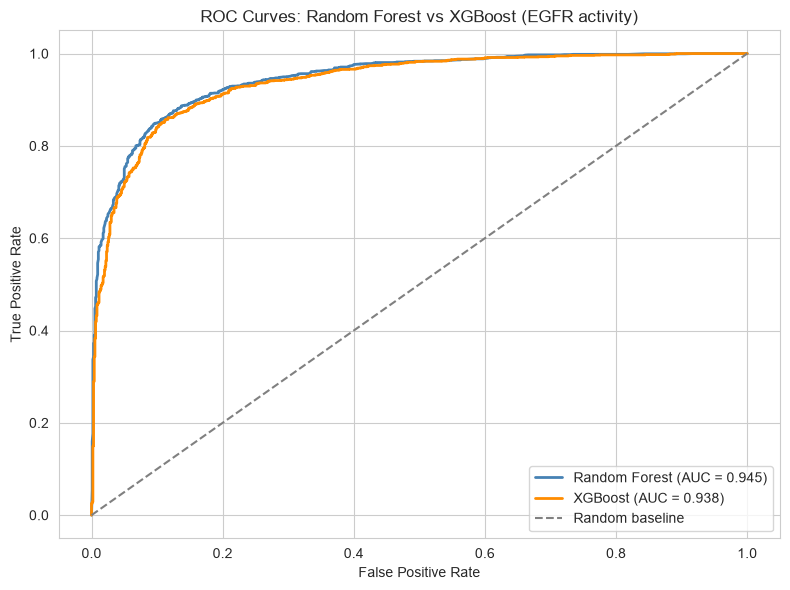

In [5]:
# ROC curves for both models
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, color='steelblue', lw=2, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(xgb_fpr, xgb_tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {xgb_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Random Forest vs XGBoost (EGFR activity)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('results/plots/roc_rf_vs_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

## Random Forest vs XGBoost

Both models were trained on Morgan fingerprints using a
stratified 80/20 train/test split (10,814 training molecules, 2,704
test molecules), with class weighting to handle the 64.5% / 35.5%
active/inactive imbalance.

| Model | ROC-AUC | Active recall | Inactive recall |
|-------|---------|---------------|-----------------|
| Random Forest (500 trees) | 0.945 | 0.89 | 0.85 |
| XGBoost (500 trees) | 0.938 | 0.89 | 0.84 |

The two models perform almost identically. A difference of 0.007 AUC
on a single split is within the expected variation, so neither model
can be called better from this experiment alone.

A random split tends to give optimistic results on
molecular data, because structurally similar molecules from the same
chemical series can fall in both the training and test sets. A
scaffold split provides a stricter estimate of how the
models generalize to new chemical series.

In [6]:
from collections import defaultdict
from rdkit.Chem.Scaffolds import MurckoScaffold

# Murcko scaffold
def get_scaffold(smiles):
    return MurckoScaffold.MurckoScaffoldSmiles(smiles=smiles, includeChirality=False)

df['scaffold'] = df['canonical_smiles'].apply(get_scaffold)
print("Unique scaffolds:", df['scaffold'].nunique())

# Group molecule indices by scaffold
scaffold_sets = defaultdict(list)
for idx, scaf in enumerate(df['scaffold']):
    scaffold_sets[scaf].append(idx)

# Fill the training set with the largest scaffold groups first (about 80%),
# the remaining (rarer) scaffolds go to the test set
sorted_sets = sorted(scaffold_sets.values(), key=lambda s: (len(s), s[0]), reverse=True)
train_cutoff = 0.8 * len(df)
train_idx, test_idx = [], []
for s in sorted_sets:
    if len(train_idx) + len(s) <= train_cutoff:
        train_idx += s
    else:
        test_idx += s

X_train_s, X_test_s = X[train_idx], X[test_idx]
y_train_s, y_test_s = y[train_idx], y[test_idx]
print("Scaffold split | Train:", X_train_s.shape, "| Test:", X_test_s.shape)
print("Train class distribution:", np.bincount(y_train_s))
print("Test class distribution:", np.bincount(y_test_s))

# Retrain both models on the scaffold split
rf_s = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42, n_jobs=-1)
rf_s.fit(X_train_s, y_train_s)
rf_s_auc = roc_auc_score(y_test_s, rf_s.predict_proba(X_test_s)[:, 1])

spw = np.bincount(y_train_s)[0] / np.bincount(y_train_s)[1]
xgb_s = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.1,
                          scale_pos_weight=spw, random_state=42, n_jobs=-1, eval_metric='logloss')
xgb_s.fit(X_train_s, y_train_s)
xgb_s_auc = roc_auc_score(y_test_s, xgb_s.predict_proba(X_test_s)[:, 1])

print(f"\nScaffold split | Random Forest AUC: {rf_s_auc:.3f} | XGBoost AUC: {xgb_s_auc:.3f}")

Unique scaffolds: 4741
Scaffold split | Train: (10814, 2048) | Test: (2704, 2048)
Train class distribution: [3671 7143]
Test class distribution: [1132 1572]

Scaffold split | Random Forest AUC: 0.890 | XGBoost AUC: 0.868


## Scaffold Split: Generalization to New Chemical Series

Molecules were grouped by Murcko scaffold (4,741 unique scaffolds) and
whole scaffold groups were assigned to either the training set (80%)
or the test set (20%). The test set therefore contains chemical
families the models have never seen during training.

| Model | Random split AUC | Scaffold split AUC |
|-------|------------------|--------------------|
| Random Forest | 0.945 | 0.890 |
| XGBoost | 0.938 | 0.868 |

Performance drops for both models when evaluated on unseen scaffolds,
which confirms that the random-split numbers were optimistic. The
scaffold-split AUC (0.890 for Random Forest) is the more realistic
estimate of how the model would behave on new chemical series, and is
the figure reported as the main result of this project.

Random Forest scores slightly higher than XGBoost on both splits. With
a single deterministic split and a single seed, this difference is
suggestive but not conclusive.

In [8]:
desc_cols = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA', 'NumRotatableBonds']
D = df[desc_cols].values
D_train, D_test = D[train_idx], D[test_idx]

def eval_rf(X_tr, X_te, name):
    m = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42, n_jobs=-1)
    m.fit(X_tr, y_train_s)
    auc = roc_auc_score(y_test_s, m.predict_proba(X_te)[:, 1])
    print(f"{name}: AUC = {auc:.3f}")
    return auc

auc_fp = rf_s_auc  # fingerprints only, already computed
auc_desc = eval_rf(D_train, D_test, "Descriptors only")
auc_both = eval_rf(np.hstack([X_train_s, D_train]), np.hstack([X_test_s, D_test]), "Fingerprints + descriptors")
print(f"Fingerprints only: AUC = {auc_fp:.3f}")

Descriptors only: AUC = 0.744
Fingerprints + descriptors: AUC = 0.892
Fingerprints only: AUC = 0.890


## Feature Comparison: Fingerprints vs Descriptors

Random Forest models were trained on the scaffold split using three
feature sets.

| Features | ROC-AUC |
|----------|---------|
| 6 Lipinski-related descriptors | 0.744 |
| Morgan fingerprints (2048 bits) | 0.890 |
| Fingerprints + descriptors | 0.892 |

Descriptors alone carry some signal but are far less informative than
fingerprints. Adding them to the fingerprints changes AUC by 0.002,
which is within expected variation, so fingerprints alone are used in
the rest of the pipeline for simplicity.